# A/B Testing Analysis of Digital Campaigns: Evaluating Conversion Rates and Business Impact

## Introduction

A/B testing is a powerful method for evaluating the effectiveness of a change in a product, marketing strategy, or user experience. In digital marketing, A/B testing can be used to compare the performance of difference campaigns or changes by measuing conversion rates and user engagement. 

In this project, we analyze data from a digital marketing experiment comparing two groups: a treatment group exposed to advertisements and a control group exposed to PSAs. The primary objective is to determine whether the advertisement campaign significantly increases conversion rates. To evaluate the effectiveness of the campaign, we perform exploratory data cleaning and preparation, assess sample size adequacy and statistical power, conduct a two-proportion z-test, construct confidence intervals, and visualize the differences in conversion performance between groups.

Additionally, we investigate how conversion behavior varies across days of the week to identify potential temporal patterns in campaign effectiveness. Through statistical analysis and visualization, this project demonstrates how hypothesis testing and data-driven decision making can be applied to real-world business and marketing problems.



## Data Cleaning and Preparation

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/marketing_AB.csv")

df["ad"] = df["test group"].apply(lambda x: 1 if x.strip() == "ad" else 0)
df.head()

,index,user id,test group,converted,total ads,most ads day,most ads hour,ad
0,0,1069124,ad,False,130,Monday,20,1
1,1,1119715,ad,False,93,Tuesday,22,1
2,2,1144181,ad,False,21,Tuesday,18,1
3,3,1435133,ad,False,355,Tuesday,10,1
4,4,1015700,ad,False,276,Friday,14,1


In [3]:
df.isna().sum()

index            0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
ad               0
dtype: int64

In [4]:
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespace from column names

We want to see how the conversion rates differ between the two groups (A and B). We can calculate the conversion rate for each group and then perform a statistical test to see if the difference is statistically significant. Group A is the control (PSA) group, and Group B is the treatment group (ad). We will use a two-proportion z-test and a 95% confidence interval to compare the conversion rates of the two groups.

#### Group Balance Check

In [5]:
print(df["test group"].value_counts(normalize=True))  #Highly imblanced
print(f"Overall conversion rate: {df["converted"].value_counts(normalize=True)[True]:.2%}")

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64
Overall conversion rate: 2.52%


### What sample size do we need to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%?

In [6]:
from statsmodels.stats.power import NormalIndPower

p1 = df[df["ad"] == 1]["converted"].mean()  # Conversion rate for the ad group
p0 = df[df["ad"] == 0]["converted"].mean()  # Conversion rate for the PSA group
#PSA / ad ratio
r = (len(df[df["ad"] == 0])/len(df[df["ad"] == 1]))  # Ratio of the sizes of the two groups
n = len(df)  # Total sample size

#Standardized effect size
effect_size = (p1 - p0) / np.sqrt(p0 * (1 - p0)) #Divides by the standard deviation of the control group
power_analysis = NormalIndPower()

n1 = power_analysis.solve_power(
    effect_size = effect_size,
    alpha       = 0.05,   # 95% confidence level
    power       = 0.80,   # 80% power, 20% chance of Type II error (false negative, failing to detect a true effect)
    ratio       = r,      # unequal group ratio
    alternative = 'two-sided'
)

n2 = n1 * r
print(f"Required sample size for the ad group (treatment): {n1:.0f}")
print(f"Required sample size for the PSA group (control): {n2:.0f}")


Required sample size for the ad group (treatment): 58148
Required sample size for the PSA group (control): 2423


#### Do we have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%?

In [7]:
if n1 + n2 <= n:
    print("We have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.")
else:
    print("We do NOT have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.")

if n1 <= len(df[df["ad"] == 1]) and n2 <= len(df[df["ad"] == 0]):
    print("We have enough samples in each group to perform the test.")
else:
    print("We do NOT have enough samples in each group to perform the test.")

We have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.
We have enough samples in each group to perform the test.


## Two-Proportion Z-Test

To test the hypothesis that the conversion rates between the two groups are different, we can use methods such as a two-proportion z-test or a confidence interval analysis. We will calculate the conversion rates for both groups and then perform the statistical test to determine if the observed difference is statistically significant.

In [8]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby('ad')['converted'].sum()
counts = df.groupby('ad')['converted'].count()
print("Conversion rates: \n", conversions / counts)
group_counts = df.groupby('ad')['converted'].count()

stat, pval = proportions_ztest(conversions, group_counts)

print("Z-stat:", stat)
print("P-value:", pval)
significance_level = 0.05
if pval < significance_level:
    print("Reject the null hypothesis: There is a significant difference in conversion rates between groups A and B.")
else:
    print("Fail to reject the null hypothesis: No significant difference detected.")

Conversion rates: 
 ad
0    0.017854
1    0.025547
Name: converted, dtype: float64
Z-stat: -7.3700781265454145
P-value: 1.7052807161559727e-13
Reject the null hypothesis: There is a significant difference in conversion rates between groups A and B.


### Confidence Intervals for Conversion Rates

In [9]:
p_ad = df[df['ad']==1]['converted'].mean()
p_psa = df[df['ad']==0]['converted'].mean()

n_ad = len(df[df['ad']== 1])
n_psa = len(df[df['ad']==0])

diff = p_ad - p_psa

se = np.sqrt((p_ad*(1-p_ad)/n_ad) + (p_psa*(1-p_psa)/n_psa))
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Difference = {diff} \n95% Confidence interval: ({ci_lower}, {ci_upper})")

Difference = 0.007692453192201517 
95% Confidence interval: (0.00595090043017032, 0.009434005954232714)


Since 0 is not included in the 95% confidence interval, we can conclude that there is a statistically significant difference in conversion rates between the two groups. This suggests that the ad group has an estimated 0.77% higher conversion rate compared to the PSA group, and the observed difference is unlikely to be due to random chance.

## Visualizations

### Confidence Interval Plot

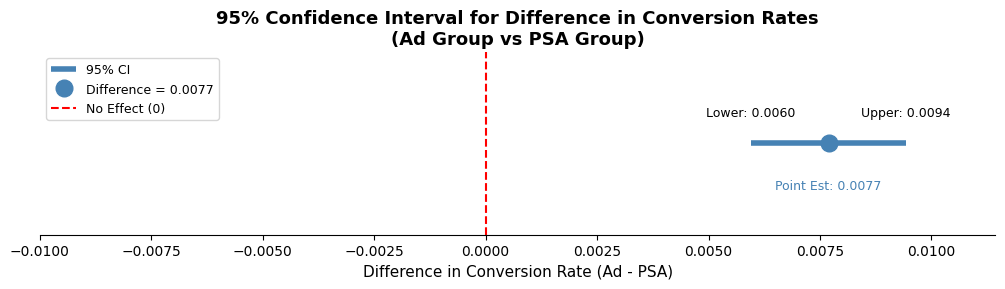

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

# Plot the CI as a horizontal line
ax.hlines(y=0, xmin=ci_lower, xmax=ci_upper, linewidth=4, color='steelblue', label='95% CI')

# Plot the point estimate (diff)
ax.plot(diff, 0, 'o', color='steelblue', markersize=12, zorder=5, label=f'Difference = {diff:.4f}')

# Add vertical line at zero to show significance boundary
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='No Effect (0)')

# Annotate the bounds
ax.text(ci_lower, 0.15, f'Lower: {ci_lower:.4f}', ha='center', fontsize=9, color='black')
ax.text(ci_upper, 0.15, f'Upper: {ci_upper:.4f}', ha='center', fontsize=9, color='black')
ax.text(diff, -0.25, f'Point Est: {diff:.4f}', ha='center', fontsize=9, color='steelblue')

# Formatting
ax.set_xlim(ci_lower - 0.002, ci_upper + 0.002)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel('Difference in Conversion Rate (Ad - PSA)', fontsize=11)
ax.set_title('95% Confidence Interval for Difference in Conversion Rates\n(Ad Group vs PSA Group)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ci_plot.png', dpi=150, bbox_inches='tight')
plt.xlim(-0.01, ci_upper + 0.002)
plt.show()

Since the entire confidence interval is above 0, we can conclude that the ad group has a statistically significantly higher conversion rate than the PSA group at the 95% confidence level. This suggests that the ad campaign is effective in increasing conversion rates compared to the PSA group.

### Conversion Rate Comparison Bar Chart

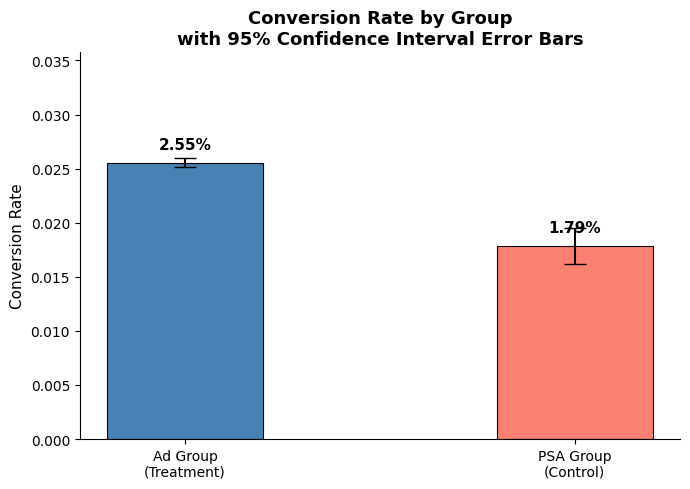

In [11]:
groups = ['Ad Group\n(Treatment)', 'PSA Group\n(Control)']
rates = [p_ad, p_psa]

# Error bars = half-width of each group's 95% CI
se_ad  = np.sqrt(p_ad  * (1 - p_ad)  / n_ad)
se_psa = np.sqrt(p_psa * (1 - p_psa) / n_psa)
errors = [1.96 * se_ad, 1.96 * se_psa]

colors = ['steelblue', 'salmon']

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(groups, rates, color=colors, width=0.4,
              yerr=errors, capsize=8, edgecolor='black', linewidth=0.8)

# Annotate each bar with its rate
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{rate:.2%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Conversion Rate', fontsize=11)
ax.set_title('Conversion Rate by Group\nwith 95% Confidence Interval Error Bars',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('conversion_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The height between the conversion rate bars shows the magnitude of the lift difference between the ad group and the PSA group. The error bars represent the 95% confidence intervals for each group's conversion rate, indicating the range of statistically reasonable values for the true conversion rates based on the sample data. If the error bars do not overlap, it suggests a statistically significant difference between the two groups. In this case, since the ad group's confidence interval does not overlap with that of the PSA group, we can infer that the ad campaign has a statistically significantly higher conversion rate compared to the PSA group.

### Conversion Rate by Day

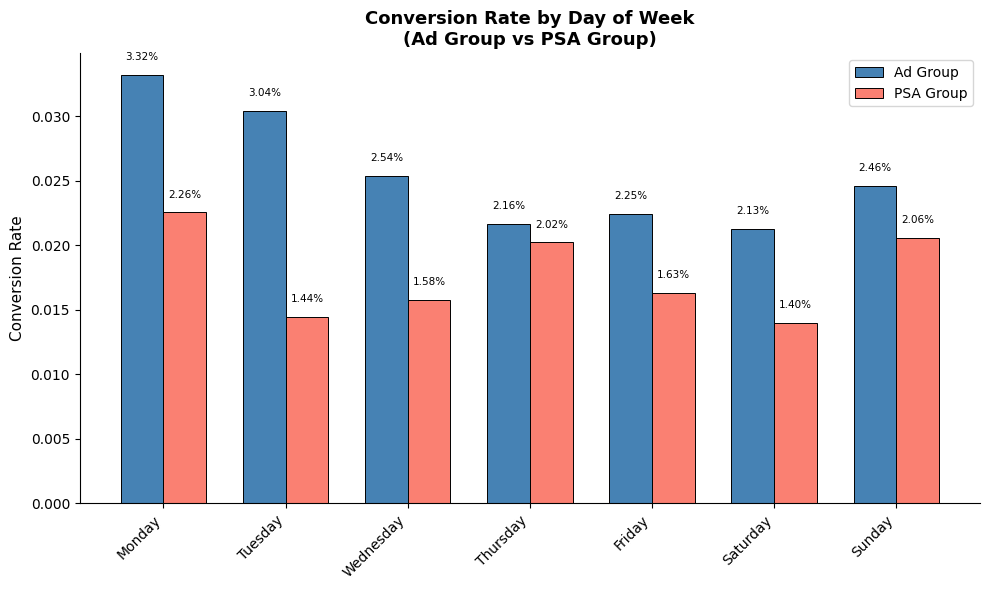

In [12]:
import matplotlib.pyplot as plt

# Day order for proper sorting
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day and calculate conversion rate for each group
day_ad  = df[df['ad'] == 1].groupby('most ads day')['converted'].mean()
day_psa = df[df['ad'] == 0].groupby('most ads day')['converted'].mean()

# Reindex to enforce day order
day_ad  = day_ad.reindex(days)
day_psa = day_psa.reindex(days)

x = range(len(days))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - width/2 for i in x], day_ad,  width, label='Ad Group',  color='steelblue', edgecolor='black', linewidth=0.7)
bars2 = ax.bar([i + width/2 for i in x], day_psa, width, label='PSA Group', color='salmon',    edgecolor='black', linewidth=0.7)

# Annotate bars with rate values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=7.5)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(list(x))
ax.set_xticklabels(days, rotation=45, ha='right')
ax.set_ylabel('Conversion Rate', fontsize=11)
ax.set_title('Conversion Rate by Day of Week\n(Ad Group vs PSA Group)', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('conversion_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

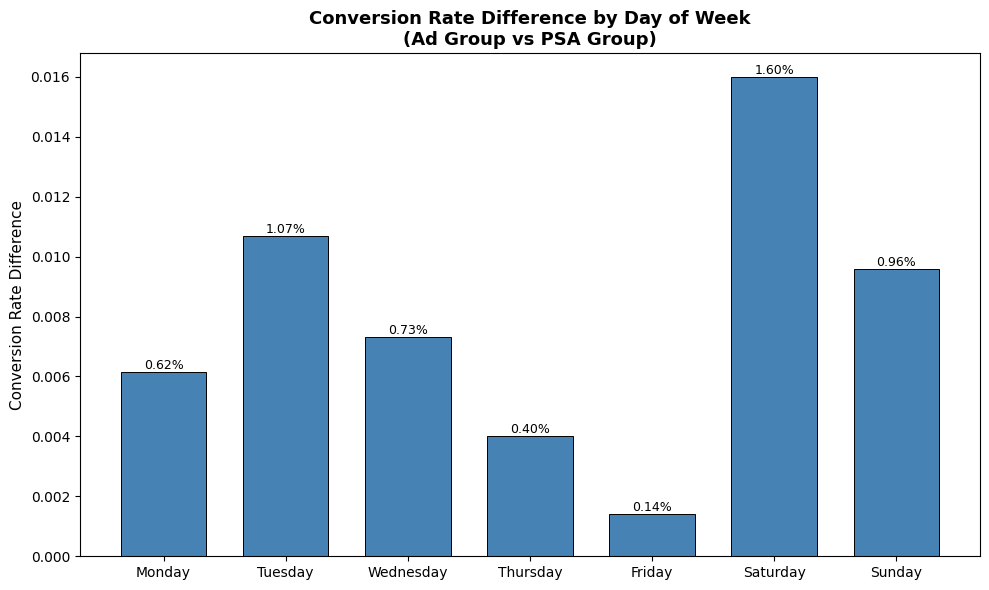

In [ ]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day and calculate conversion rate for each group
day_ad  = df[df['ad'] == 1].groupby('most ads day')['converted'].mean()
day_psa = df[df['ad'] == 0].groupby('most ads day')['converted'].mean()

#Calculate the difference in conversion rates by day
day_diff = day_ad - day_psa

# Reindex to enforce day order
day_ad  = day_ad.reindex(days)
day_psa = day_psa.reindex(days)

x = range(len(days))
width = 0.7

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar([i - width/2 for i in x], day_diff,  width, label='Ad Group',  color='steelblue', edgecolor='black', linewidth=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() ,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks([i - width/2 for i in x]) #Centered x-ticks
ax.set_xticklabels(days) # Day labels
ax.set_ylabel('Conversion Rate Difference', fontsize=11)
ax.set_title('Conversion Rate Difference by Day of Week\n(Ad Group vs PSA Group)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('conversion_by_day.png', dpi=150, bbox_inches='tight')
plt.show()